In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dense, Dropout, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
df = pd.read_csv("fer2013.csv")

# Remove original emotions 'disgust' (label 1) and 'surprise' (label 5)
df = df[df['emotion'] != 1]
df = df[df['emotion'] != 5]

# Remap the remaining original labels (0, 2, 3, 4, 6) to a contiguous range (0, 1, 2, 3, 4)
label_map = {
    0: 0,  # anger
    2: 1,  # fear
    3: 2,  # happiness
    4: 3,  # sadness
    6: 4   # neutral (original label 6 becomes new label 4)
}

df['emotion'] = df['emotion'].map(label_map)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31338 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  31338 non-null  int64 
 1   pixels   31338 non-null  object
 2   Usage    31338 non-null  object
dtypes: int64(1), object(2)
memory usage: 979.3+ KB


In [27]:
temp_pixels = df["pixels"].apply(lambda x: np.array(x.split(), dtype=np.uint8))

# Filter out rows where the pixel array does not have 2304 elements
valid_pixels_mask = temp_pixels.apply(len) == 2304
df_filtered = df[valid_pixels_mask].copy()
temp_pixels_filtered = temp_pixels[valid_pixels_mask]

# Drop rows with NaN emotions
df_filtered.dropna(subset=['emotion'], inplace=True)
temp_pixels_filtered = temp_pixels_filtered[df_filtered.index]

# Now, reshape the valid pixel arrays and stack them into X
X = np.stack(temp_pixels_filtered.apply(lambda x: x.reshape(48, 48)))

# Extract y from the filtered DataFrame
y = df_filtered['emotion'].values

# Normalize X
X = X / 255.0

In [28]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42) # 0.25 * 0.8 = 0.2 of original data

# Reshape X for CNN input (add channel dimension)
X_train = X_train.reshape(X_train.shape[0], 48, 48, 1)
X_val = X_val.reshape(X_val.shape[0], 48, 48, 1)
X_test = X_test.reshape(X_test.shape[0], 48, 48, 1)

# Define the number of classes
num_classes = len(np.unique(y_train_full))

# One-hot encode y
y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (18802, 48, 48, 1), y_train shape: (18802, 5)
X_val shape: (6268, 48, 48, 1), y_val shape: (6268, 5)
X_test shape: (6268, 48, 48, 1), y_test shape: (6268, 5)


In [42]:
# Calculate class weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_full),
    y=y_train_full
)
class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.2516225661507738), 1: np.float64(1.2274173806609547), 2: np.float64(0.6980370318808298), 3: np.float64(1.0353086929589097), 4: np.float64(1.01231576822128)}


In [43]:
from tensorflow.keras.layers import Input

# Define the VGG-like model
model = Sequential()
model.add(Input(shape=(48, 48, 1)))

# VGG Block 1: Two Conv2D layers with 64 filters
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# VGG Block 2: Two Conv2D layers with 128 filters
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# VGG Block 3: Three Conv2D layers with 256 filters
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same')) # Added another Conv2D
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,462,661 (24.65 MB)

 Trainable params: 6,459,333 (24.64 MB)

 Non-trainable params: 3,328 (13.00 KB)

In [44]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

In [45]:
# Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# Train the model with data augmentation and class weights
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50, # You can adjust this based on performance
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stopping],
    class_weight=class_weights_dict
)

Epoch 1/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.2449 - loss: 1.9595 - val_accuracy: 0.1637 - val_loss: 2.4938 - learning_rate: 0.0010
Epoch 2/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.3234 - loss: 1.6508 - val_accuracy: 0.3084 - val_loss: 1.5705 - learning_rate: 0.0010
Epoch 3/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.4108 - loss: 1.4582 - val_accuracy: 0.4756 - val_loss: 1.2624 - learning_rate: 0.0010
Epoch 4/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.4662 - loss: 1.3371 - val_accuracy: 0.4343 - val_loss: 1.5266 - learning_rate: 0.0010
Epoch 5/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.4943 - loss: 1.2778 - val_accuracy: 0.5080 - val_loss: 1.2139 - learning_rate: 0.0010
Epoch 6/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.5266 - loss: 1.2153 - val_accuracy: 0.5523 - val_loss: 1.0963 - learning_rate: 0.0010
Epoch 7/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.5488 - l

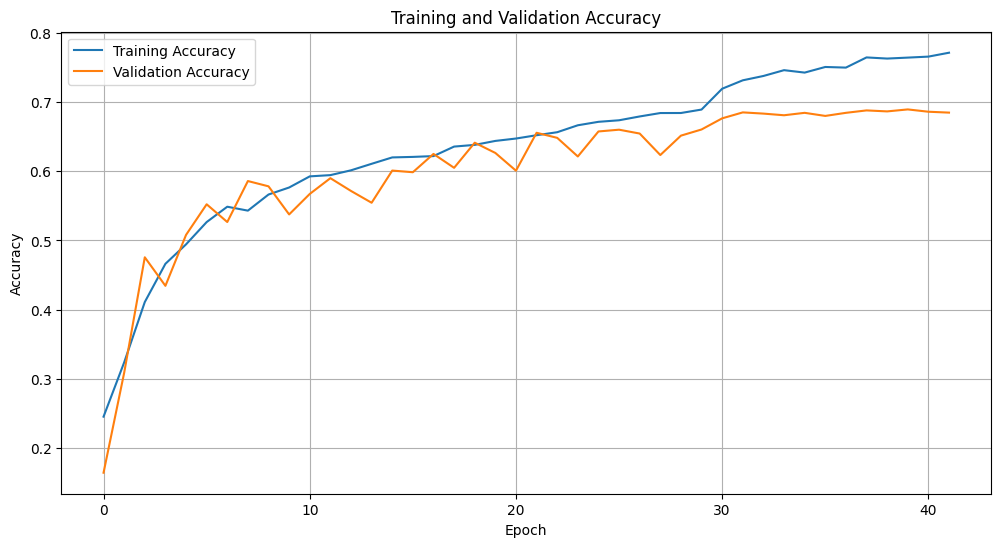

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.60       947
           1       0.58      0.53      0.55      1036
           2       0.90      0.86      0.88      1806
           3       0.60      0.53      0.56      1234
           4       0.61      0.71      0.66      1245

    accuracy                           0.68      6268
   macro avg       0.65      0.65      0.65      6268
weighted avg       0.68      0.68      0.68      6268



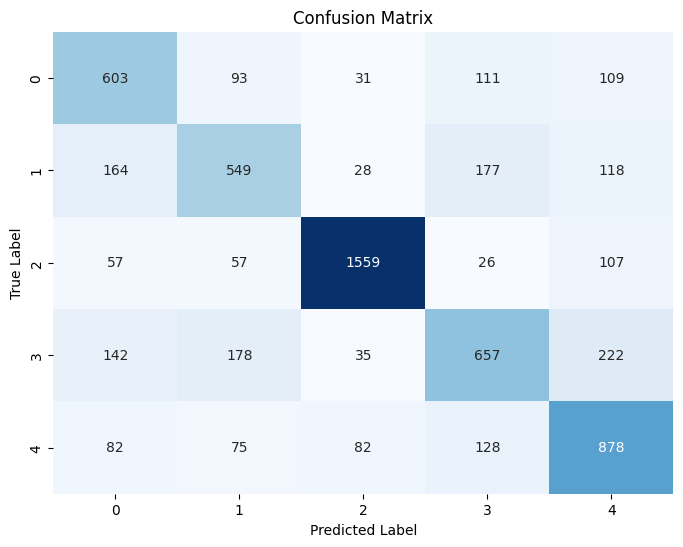

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict probabilities on the test set
y_pred_probs = model.predict(X_test)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)
# Convert one-hot encoded y_test back to class labels
y_true = np.argmax(y_test, axis=1)

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Image Preprocessing Pipeline for New Data

To apply the trained model to new images, we need a preprocessing pipeline that mirrors the steps taken during the preparation of the training data. This involves:
1.  **Face Detection**: Using a Haar Cascade classifier to locate faces.
2.  **Cropping and Resizing**: Extracting the detected face, ensuring it's square, and resizing it to 48x48 pixels.
3.  **Normalization**: Scaling pixel values to the 0-1 range.
4.  **Reshaping**: Adding the channel dimension (1) as expected by the CNN model.

In [48]:
import cv2

# Download the Haar Cascade classifier for face detection if not already present
# This is a pre-trained model for detecting frontal faces
HAAR_CASCADE_URL = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
HAAR_CASCADE_FILENAME = "haarcascade_frontalface_default.xml"

import os
import urllib.request

if not os.path.exists(HAAR_CASCADE_FILENAME):
    print(f"Downloading {HAAR_CASCADE_FILENAME}...")
    urllib.request.urlretrieve(HAAR_CASCADE_URL, HAAR_CASCADE_FILENAME)
    print("Download complete.")
else:
    print(f"{HAAR_CASCADE_FILENAME} already exists.")

# Load the Haar Cascade classifier
face_cascade = cv2.CascadeClassifier(HAAR_CASCADE_FILENAME)

def preprocess_image_for_model(image_path):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 2. Convert to grayscale (model expects single channel)
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Detect faces in the image
    faces = face_cascade.detectMultiScale(
        gray_img,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) == 0:
        print("No faces detected in the image.")
        return None

    # For simplicity, take the first detected face (you might want to select the largest face for better results)
    (x, y, w, h) = faces[0]

    # 4. Crop the detected face
    face_roi = gray_img[y:y+h, x:x+w]

    # 5. Resize to 48x48 pixels
    resized_face = cv2.resize(face_roi, (48, 48))

    # 6. Normalize pixel values to 0.0-1.0
    normalized_face = resized_face / 255.0

    # 7. Reshape to add a channel dimension (48, 48, 1) as expected by the model
    model_input = normalized_face.reshape(1, 48, 48, 1) # Add batch dimension too

    return model_input


Download complete.


### Demo of the preprocessing pipeline

To test the `preprocess_image_for_model` function, you can upload an image to your Colab environment. Once uploaded, replace `'path/to/your/image.jpg'` with the actual path to your image file. The processed image will be ready for prediction by the trained model.

Shape of processed input for model: (1, 48, 48, 1)


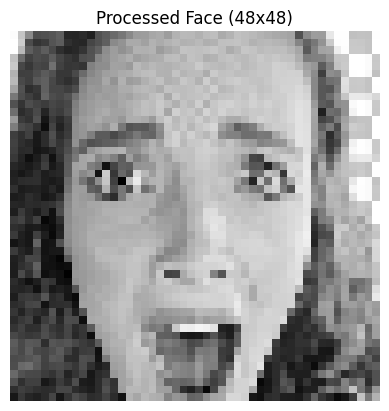

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Predicted emotion class: 1
Predicted emotion name: fear


In [56]:
# Example Usage:
# Upload an image to your Colab environment (e.g., drag and drop into the files section)
# Then, specify the path to your uploaded image.

# In a real scenario, you would use an actual image from the user.
import matplotlib.pyplot as plt
from PIL import Image

# If you have an actual image, replace 'dummy_face_image.png' with its path
# For example: image_to_process = 'my_uploaded_face.jpg'
image_to_process = "/content/2833459-shot-of-a-young-woman-looking-scared-against-isolated-on-png-background-fit_400_400.jpg"

# Define the emotion map (copied from earlier in the notebook for easy reference)
# Remap the remaining original labels (0, 2, 3, 4, 6) to a contiguous range (0, 1, 2, 3, 4)


processed_input = preprocess_image_for_model(image_to_process)

if processed_input is not None:
    print("Shape of processed input for model:", processed_input.shape)

    # Visualize the processed face
    plt.imshow(processed_input[0, :, :, 0], cmap='gray')
    plt.title('Processed Face (48x48)')
    plt.axis('off')
    plt.show()

    # Now you can use this `processed_input` with your model for prediction
    prediction = model.predict(processed_input)
    predicted_class = np.argmax(prediction)
    predicted_emotion_name = emotion_map.get(predicted_class, 'Unknown')
    print("Predicted emotion class:", predicted_class)
    print("Predicted emotion name:", predicted_emotion_name)
else:
    print("Image processing failed or no face detected.")

### Pickling the End-to-End Emotion Recognition Pipeline

To create a truly portable pipeline, we'll define a class that encapsulates both the trained Keras model and the Haar Cascade face detector. This class will handle loading these components from their saved paths and provide a single method for processing an image and predicting its emotion. An instance of this class can then be pickled and unpickled, effectively saving your entire workflow.

In [66]:
import tensorflow as tf
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os # Added for os.path.exists

# Ensure the model is saved (if not already from previous steps)
model_save_path = "emotion_recognition_model.keras"
if not os.path.exists(model_save_path):
    print(f"Saving model to {model_save_path}...")
    model.save(model_save_path)

class EmotionRecognitionPipeline:
    def __init__(self, model_path, cascade_path):
        print("Initializing EmotionRecognitionPipeline...")
        self.model_path = model_path
        self.cascade_path = cascade_path
        self.emotion_map = {
          0: 'anger',
          1: 'fear',
          2: 'happiness',
          3: 'sadness',
          4: 'neutral'
        }

        # Load these non-picklable objects on initialization
        self._model = tf.keras.models.load_model(self.model_path)
        print(f"Keras model loaded from {self.model_path}")
        self._face_cascade = cv2.CascadeClassifier(self.cascade_path)
        if self._face_cascade.empty():
            raise IOError(f"Could not load Haar Cascade classifier from {self.cascade_path}")
        print(f"Haar Cascade classifier loaded from {self.cascade_path}")
        print("Pipeline initialized successfully.")

    # Method to define what gets pickled
    def __getstate__(self):
        state = self.__dict__.copy()
        # Remove the unpicklable objects
        del state['_model']
        del state['_face_cascade']
        return state

    # Method to define how to unpickle
    def __setstate__(self, state):
        self.__dict__.update(state)
        # Reload the unpicklable objects using their paths
        self._model = tf.keras.models.load_model(self.model_path)
        self._face_cascade = cv2.CascadeClassifier(self.cascade_path)
        if self._face_cascade.empty():
            raise IOError(f"Could not load Haar Cascade classifier from {self.cascade_path}")

    def preprocess_and_predict(self, image_path, display_image=True):
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Could not load image from {image_path}")
            return None, None, None

        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces = self._face_cascade.detectMultiScale( # Use self._face_cascade
            gray_img,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )

        if len(faces) == 0:
            print("No faces detected in the image.")
            return None, None, None

        (x, y, w, h) = faces[0]
        face_roi = gray_img[y:y+h, x:x+w]
        resized_face = cv2.resize(face_roi, (48, 48))
        normalized_face = resized_face / 255.0
        model_input = normalized_face.reshape(1, 48, 48, 1)

        # Make prediction
        prediction = self._model.predict(model_input) # Use self._model
        predicted_class = np.argmax(prediction)
        predicted_emotion_name = self.emotion_map.get(predicted_class, 'Unknown')

        if display_image:
            plt.imshow(model_input[0, :, :, 0], cmap='gray')
            plt.title(f'Detected Face (48x48) - Predicted: {predicted_emotion_name}')
            plt.axis('off')
            plt.show()

        return predicted_class, predicted_emotion_name, prediction


In [67]:
# Define necessary paths and mappings (ensure HAAR_CASCADE_FILENAME is defined earlier)
# emotion_map was defined in a previous cell.

# Create an instance of the pipeline
full_pipeline = EmotionRecognitionPipeline(
    model_path=model_save_path,
    cascade_path=HAAR_CASCADE_FILENAME
)

# Save the entire pipeline instance using pickle
pipeline_pickle_path = "emotion_recognition_pipeline.pkl"
with open(pipeline_pickle_path, 'wb') as f:
    pickle.dump(full_pipeline, f)
print(f"Full pipeline pickled to {pipeline_pickle_path}")

# Load the pipeline instance from the pickle file
with open(pipeline_pickle_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)
print(f"Pipeline unpickled from {pipeline_pickle_path}")

Initializing EmotionRecognitionPipeline...
Keras model loaded from emotion_recognition_model.keras
Haar Cascade classifier loaded from haarcascade_frontalface_default.xml
Pipeline initialized successfully.
Full pipeline pickled to emotion_recognition_pipeline.pkl
Pipeline unpickled from emotion_recognition_pipeline.pkl



Testing the unpickled pipeline:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


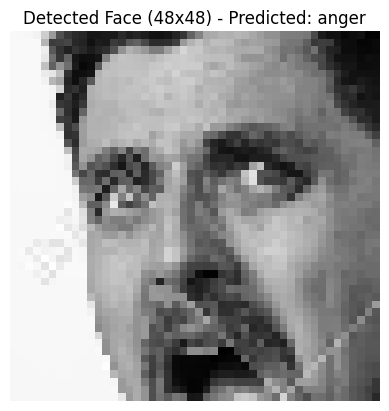

Predicted emotion for /content/143266307-the-man-is-afraid-of-fear.jpg: anger (Class ID: 0)

Confidence Breakdown:
  anger: 0.3378
  fear: 0.2165
  happiness: 0.0027
  sadness: 0.1553
  neutral: 0.2877


In [69]:
# Demonstrate using the unpickled pipeline
print("\nTesting the unpickled pipeline:")
image_for_test = "/content/143266307-the-man-is-afraid-of-fear.jpg"

predicted_class_id, predicted_emotion, confidence_scores = loaded_pipeline.preprocess_and_predict(
    image_for_test,
    display_image=True
)

if predicted_emotion:
    print(f"Predicted emotion for {image_for_test}: {predicted_emotion} (Class ID: {predicted_class_id})")
    print("\nConfidence Breakdown:")
    for i, score in enumerate(confidence_scores[0]):
        emotion_name = loaded_pipeline.emotion_map.get(i, 'Unknown')
        print(f"  {emotion_name}: {score:.4f}")
else:
    print(f"Failed to predict emotion for {image_for_test}.")
